In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.metrics import accuracy_score
from IPython.display import display, Image, clear_output 

# PyTorch
import torch
from torch.utils import data
import torch.nn as nn
from torch.nn.functional import mse_loss, l1_loss, cross_entropy
from torch import optim

# 30760 plotting routines
import utility_30760 as util

OSError: [WinError 127] The specified procedure could not be found. Error loading "c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\.pixi\envs\default\Lib\site-packages\torch\lib\shm.dll" or one of its dependencies.

# MNIST classification with a feed-forward network

1. Load data
- Implement dataloader
- Design network
- Design error/loss function
- Train and validate the network
- Evaluate performance


## Load data

In [ ]:
# Load a subset of the full MNIST dataset
N_mnist = 2000

mnist = np.load('mnist.npz')
num_classes = 10
x_mnist = mnist['X_train'][:N_mnist].astype('float32')
labels_mnist = mnist['y_train'][:N_mnist].astype('int32')

print("x_mnist:\t", x_mnist.shape)
print("labels_mnist:\t", labels_mnist.shape)

x_mnist:	 (2000, 784)
labels_mnist:	 (2000,)


In [ ]:
# Display labels
print(labels_mnist[:100])

[5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9 4 0 9 1 1 2 4 3 2 7 3 8 6 9 0 5 6
 0 7 6 1 8 7 9 3 9 8 5 9 3 3 0 7 4 9 8 0 9 4 1 4 4 6 0 4 5 6 1 0 0 1 7 1 6
 3 0 2 1 1 7 9 0 2 6 7 8 3 9 0 4 6 7 4 6 8 0 7 8 3 1]


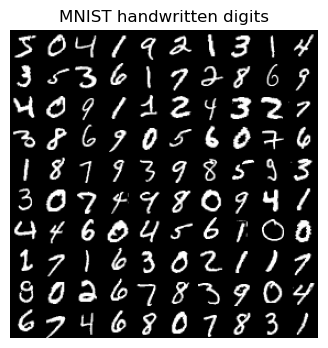

In [ ]:
#plot a few MNIST examples
idx, dim, classes, len_mnist = 0, 28, 10, 784
# create empty canvas
canvas = np.zeros((dim*classes, classes*dim))

# fill with tensors
for i in range(classes):
    for j in range(classes):
        canvas[i*dim:(i+1)*dim, j*dim:(j+1)*dim] = x_mnist[idx].reshape((dim, dim))
        idx += 1

# visualize matrix of tensors as gray scale image
plt.figure(figsize=(4, 4))
plt.axis('off')
plt.imshow(canvas, cmap='gray')
plt.title('MNIST handwritten digits')
plt.show()

## Set up dataloader

In [ ]:
class Dataset(data.Dataset):
    "Characterizes a dataset for PyTorch"
    def __init__(self, list_IDs, labels, x):
            'Initialization'
            self.list_IDs = list_IDs
            self.labels = labels
            self.x = x

    def __len__(self):
            'Denotes the total number of samples'
            return len(self.list_IDs)

    def __getitem__(self, index):
            'Generates one sample of data'
            # Select sample
            ID = self.list_IDs[index]

            # Load data and get label
            x = torch.from_numpy(self.x[ID,:]).float()
            y = self.labels[ID]

            return x, y

In [ ]:
split_frac = 0.75 # Split into training and validation data
batch_size = 100

# data ID
labels_ID = np.arange(0,len(labels_mnist))
labels_tuple = zip(labels_ID, labels_mnist)

# Partition IDs
idx_split_data = int(split_frac*N_mnist)
partition = {"train": labels_ID[:idx_split_data], "validation": labels_ID[idx_split_data:]} # IDs
labels = {ID: label for (ID, label) in labels_tuple} # Labels

# Parameters
DL_params = {'batch_size': batch_size, 'shuffle': True}

# Generators
training_set = Dataset(partition['train'], labels, x_mnist)
training_generator = data.DataLoader(training_set, **DL_params)

validation_set = Dataset(partition['validation'], labels, x_mnist)
validation_generator = data.DataLoader(validation_set, **DL_params)

### Display walkthrough of batches

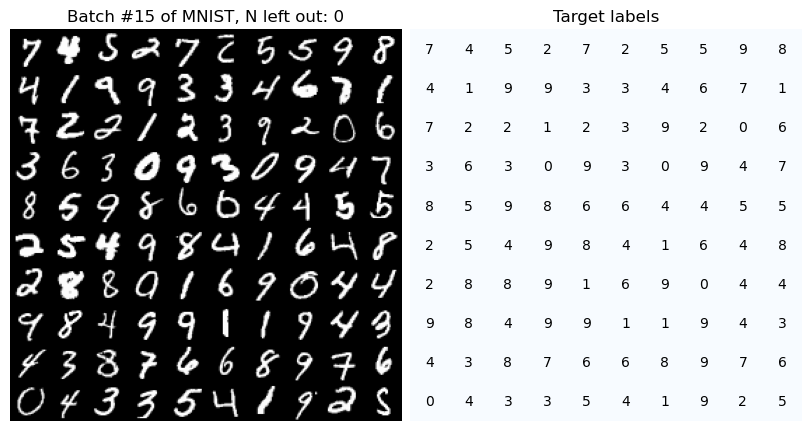

In [ ]:
count = 1
fig = plt.figure(figsize=(8,8), constrained_layout=True) # Initiate figure with constrained layout
gs = fig.add_gridspec(1, 2) # Add 1x2 grid
ax1 = fig.add_subplot(gs[0, 0]) 
ax2 = fig.add_subplot(gs[0, 1]) 

# WALK THROUGH TRAINING SET
for x_train, y_train in training_generator:
    
    # Initiation parameters
    canvas_size = int(np.sqrt(x_train.shape[0]))
    ax2.clear()
    ax2.set_title("Target labels")
    ax2.imshow(np.zeros((canvas_size, canvas_size)), cmap=plt.cm.Blues)
    canvas = np.zeros((dim*canvas_size, canvas_size*dim))
    batch_left_out = x_train.shape[0] - canvas_size**2
    idx = 0  
    
    # WALK THROUGH EACH BATCH
    for i in range(canvas_size):
        for j in range(canvas_size):
            
            canvas[i*dim:(i+1)*dim, j*dim:(j+1)*dim] = x_train[idx].reshape((dim, dim)) 
            ax2.text(j, i, str(y_train.detach().numpy()[idx]), va='center', ha='center')
            idx += 1     
            
    # Finalize plots
    ax1.clear()
    ax1.set_title("Batch #{} of MNIST, N left out: {}".format(count,batch_left_out))
    ax1.imshow(canvas, cmap='gray')
    ax1.axis('off')
    ax2.axis('off')
    #fig.canvas.draw()
    display(fig)
    clear_output(wait=True)
    count += 1
    # Pause between each iteration
    time.sleep(0.2)

In [ ]:
print(x_train.shape)
print(y_train.shape)

torch.Size([100, 784])
torch.Size([100])


## Design network

In [ ]:
class SimpleFFN(nn.Module):
    def __init__(self, input_seq):
        super(SimpleFFN, self).__init__()
        
        # Store the input network
        self.input_seq = input_seq

    def forward(self, x): 
        outputs = {}

        # Forward propagate input through the network
        y = self.input_seq(x)
        
        return y

In [ ]:
input_seq = nn.Sequential(
            nn.Linear(in_features=len_mnist, out_features=3), # Hidden layer 1
            nn.Tanh(),
            nn.Linear(in_features=3, out_features=10),  # Output layer
        )

net = SimpleFFN(input_seq)

# Transfer model to GPU if available
cuda_available = torch.cuda.is_available()
#cuda_available = False # Force CPU
if cuda_available:
    device = torch.device("cuda:0" if cuda_available else "cpu")
    print("Transferring net to single available GPU:", device)

    net = net.to(device)

print(net)

SimpleFFN(
  (input_seq): Sequential(
    (0): Linear(in_features=784, out_features=3, bias=True)
    (1): Tanh()
    (2): Linear(in_features=3, out_features=10, bias=True)
  )
)


## Design error/loss function

In [ ]:
def error_func_mnist(y_out, y_t):
    
    E = cross_entropy(y_out, y_t.long(), reduction = "mean")
    
    return E

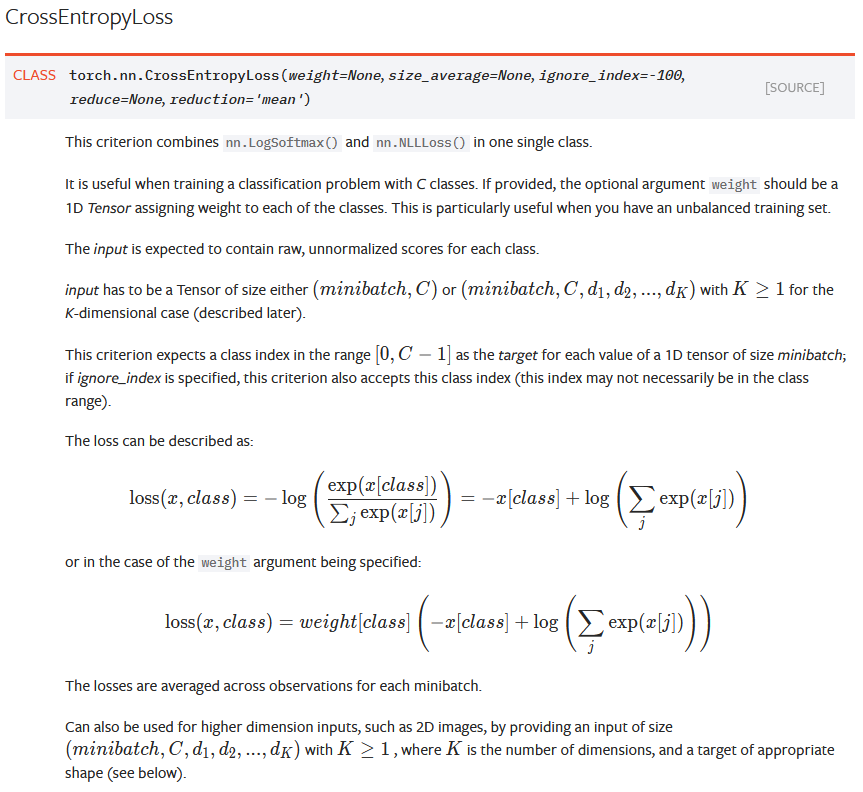

In [ ]:
Image(filename='pytorch_ce_docs.png') 

## Train and validate the network

Final training accuracy:	 72.0
Final validation accuracy:	 59.0
Run time: 42.404s


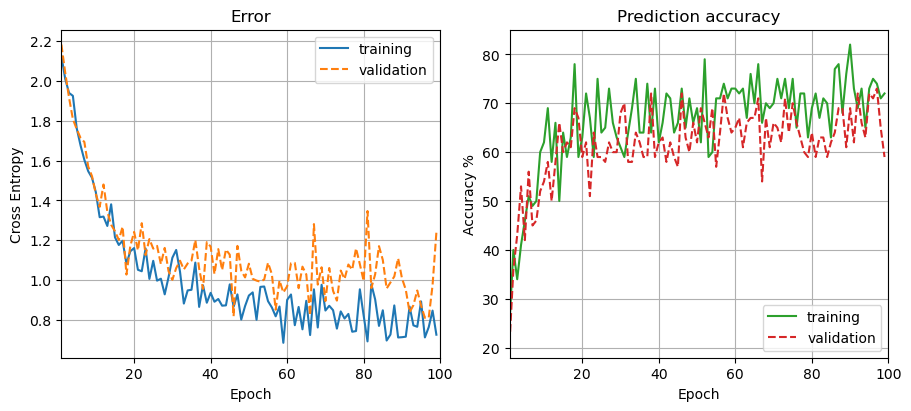

In [ ]:
optimizer = optim.SGD(net.parameters(), lr=0.1)

N_epochs = 100 

fig = plt.figure(figsize=(9,4), constrained_layout=True) # Initiate figure with constrained layout
gs = fig.add_gridspec(1, 2) # Add 1x2 grid
ax1 = fig.add_subplot(gs[0, 0]) 
ax2 = fig.add_subplot(gs[0, 1]) 

E_train_collect, E_valid_collect = [], []

acc_train_collect, acc_valid_collect = [],[]

t0 = time.time()

# Iterate over epochs
for epoch in np.arange(1,N_epochs):
    net.train() # Set network in "training mode"

    # Go through each batch in the training dataset using the loader
    for x_train, y_train in training_generator:

        if cuda_available:
            x_train = x_train.to(device)
            y_train = y_train.to(device)
        
        y_out_train = net(x_train) # Forward propagate through the network

        E_train = error_func_mnist(y_out_train, y_train) # Estimate error

        optimizer.zero_grad() # Reset gradients to zero
        E_train.backward() # Back-propagate to get the gradients based on the estimated error
        optimizer.step() # Update through the optimizer (e.g. stochastic gradient descent)
        
    # Evaluate, do not propagate gradients
    with torch.no_grad():
        net.eval() # Set network in "evaluation mode"

        # Just load a single validation batch from the test loader
        x_valid, y_valid = next(iter(validation_generator))

        if cuda_available:
            x_valid = x_valid.to(device)
            y_valid = y_valid.to(device)
        
        y_out_valid = net(x_valid) # Forward propagate the validation set

        E_valid = error_func_mnist(y_out_valid, y_valid) # Compute the validation error

    
    
    E_train_collect.append(E_train.sum().detach().cpu().numpy())
    E_valid_collect.append(E_valid.sum().detach().cpu().numpy())
    # Accuracy
    acc_train  = accuracy_score(y_train.detach().cpu().numpy(), np.argmax(y_out_train.detach().cpu().numpy(),axis=1))
    acc_train_collect.append(acc_train*100)
    acc_valid  = accuracy_score(y_valid.detach().cpu().numpy(), np.argmax(y_out_valid.detach().cpu().numpy(),axis=1))
    acc_valid_collect.append(acc_valid*100)
    
    # Finalize plots   
    ax1.clear()
    ax2.clear()
    ax1.set_title('Error')
    ax2.set_title('Prediction accuracy')
    ax1.set_xlabel("Epoch")
    ax2.set_xlabel("Epoch")
    ax1.set_ylabel("Cross Entropy")
    ax2.set_ylabel("Accuracy %")
    ax2.set_xlim([1,N_epochs])
    ax1.set_xlim([1,N_epochs])
    ax1.grid()
    ax2.grid()
    ax1.plot(np.arange(1,epoch+1), E_train_collect, '-', color="C0", label = "training")
    ax1.plot(np.arange(1,epoch+1), E_valid_collect, '--', color="C1", label = "validation")
    ax2.plot(np.arange(1,epoch+1), acc_train_collect, '-', color="C2", label = "training")
    ax2.plot(np.arange(1,epoch+1), acc_valid_collect, '--', color="C3", label = "validation")
    ax1.legend(loc="upper right")
    ax2.legend(loc="lower right")
       
    display(fig)
    clear_output(wait=True)
    
print("Final training accuracy:\t", acc_train_collect[-1])
print("Final validation accuracy:\t", acc_valid_collect[-1])

t1 = time.time()
time_take = (t1-t0)
run_time = 'Run time: {:.3f}s'.format(time_take)
print(run_time)

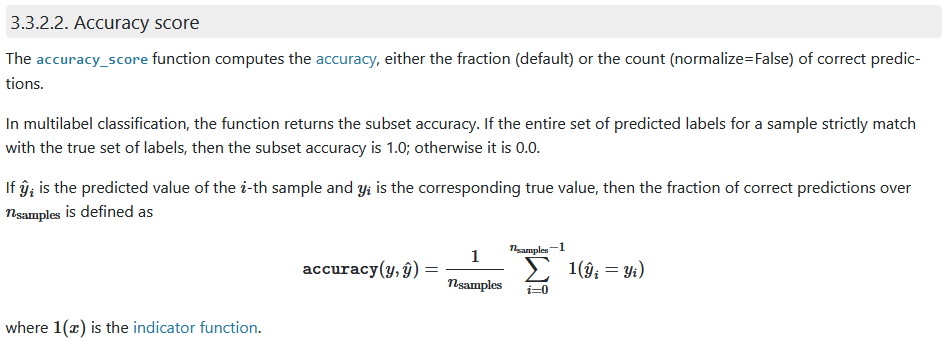

In [ ]:
Image(filename='mklearn_acc_score_docs.png')

[Sci-kit learn accuracy score documentation](https://scikit-learn.org/stable/modules/model_evaluation.html#accuracy-score)

## Evaluate performance

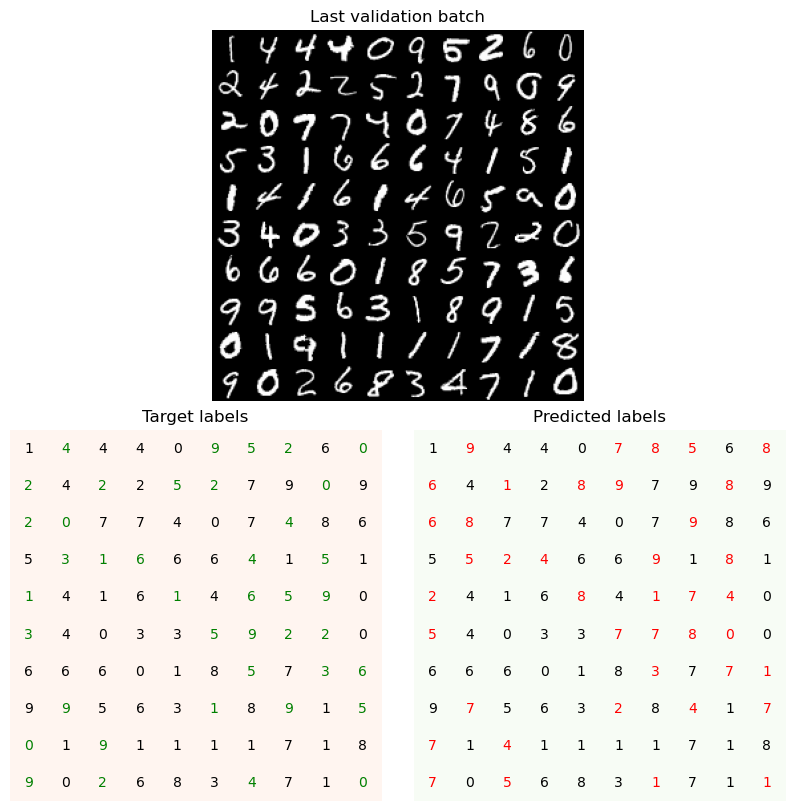

In [ ]:
count = 1
canvas_size = int(np.sqrt(x_valid.shape[0]))
fig = plt.figure(figsize=(8,8), constrained_layout=True) # Initiate figure with constrained layout
gs = fig.add_gridspec(2, 2) # Add 2x2 grid
ax1 = fig.add_subplot(gs[0, :]) 
ax2 = fig.add_subplot(gs[1, 0]) 
ax3 = fig.add_subplot(gs[1, 1])

# Initiation parameters
ax2.clear()
ax2.set_title("Target labels")
ax2.imshow(np.zeros((canvas_size, canvas_size)), cmap=plt.cm.Reds)
ax3.clear()
ax3.set_title("Predicted labels")
ax3.imshow(np.zeros((canvas_size, canvas_size)), cmap=plt.cm.Greens)
canvas = np.zeros((dim*canvas_size, canvas_size*dim))
batch_left_out = x_train.shape[0] - canvas_size**2
idx = 0 

pred_difference = np.argmax(y_out_valid.detach().cpu().numpy(),axis=1) - y_valid.detach().cpu().numpy()

# WALK THROUGH EACH BATCH
for i in range(canvas_size):
    for j in range(canvas_size):

        canvas[i*dim:(i+1)*dim, j*dim:(j+1)*dim] = x_valid.cpu()[idx].reshape((dim, dim)) 
        
        if pred_difference[idx] == 0:
            text_color_str_t = "black"
            text_color_str_p = "black"
        else:
            text_color_str_t = "green"
            text_color_str_p = "red"
        
        #print(pred_difference[idx])
        ax3.text(j, i, str(np.argmax(y_out_valid.detach().cpu().numpy(),axis=1)[idx]), va='center', ha='center', color = text_color_str_p)
        ax2.text(j, i, str(y_valid.detach().cpu().numpy()[idx]), va='center', ha='center', color = text_color_str_t)
        idx += 1     

# Finalize plots
ax1.clear()
ax1.set_title("Last validation batch")
ax1.imshow(canvas, cmap='gray')
ax1.axis('off')
ax2.axis('off')
ax3.axis('off')
fig.canvas.draw()

## Exercise 5.5

1. Make changes to the network to improve prediction accuracy. It should be possible to get validation results consistently above 90%. Keep the same MNIST dataset size, batch size, and training/validation fraction.
2. Are you confident in your networks ability to make predictions outside of the training data? why? why not?

### Suggestions for changes to the network

The numerical values used (e.g. lr or out_features) are not necessarily "best" values. You will have to find "better" values yourself.

__Network design__

More units in the hidden layer
```Python
input_seq = nn.Sequential(
            nn.Linear(in_features=len_mnist, out_features=20), # Hidden layer 1
            nn.Tanh(),
            nn.Linear(in_features=20, out_features=10)  # Output layer
        )
```

More hidden layers
```Python
input_seq = nn.Sequential(
            nn.Linear(in_features=len_mnist, out_features=3), # Hidden layer 1
            nn.Tanh(),
            nn.Linear(in_features=3, out_features=6), # Hidden layer 2
            nn.Tanh(),
            nn.Linear(in_features=6, out_features=10)  # Output layer
        )
```

Different activation functions

```Python
input_seq = nn.Sequential(
            nn.Linear(in_features=len_mnist, out_features=20), # Hidden layer 1
            nn.ReLU(),
            nn.Linear(in_features=20, out_features=10)  # Output layer
        )
```

Dropout regularization

```Python
input_seq = nn.Sequential(
            nn.Linear(in_features=len_mnist, out_features=20), # Hidden layer 1
            nn.Tanh(),
            nn.Dropout(p=0.3),
            nn.Linear(in_features=20, out_features=10)  # Output layer
        )
```


__Error function changes__

Sum reduction

```Python
E = cross_entropy(_, _, reduction = "sum")
```

__Parameter changes__

Number of epochs

```Python
N_epochs = 50
```

Learning rate

```Python
optimizer = optim.SGD(net.parameters(), lr=0.001)
```

__Different optimizers__

E.g. the Adam optimization algorithm ([Adam paper](https://arxiv.org/pdf/1412.6980.pdf))

```Python
optimizer = optim.Adam(net.parameters(), lr=0.001)
```
Find more here: https://pytorch.org/docs/stable/optim.html